# Cycling Smart City

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import folium

from sourcing_data import OpenStreetMapData, LocalGeoData, BicycleCounterData

In [5]:
local_data = LocalGeoData()
osm_data = OpenStreetMapData()
counter_data = BicycleCounterData() 

2026-03-27 19:39:34,226 - INFO - Starting local data ingestion...
2026-03-27 19:39:34,227 - WARNING - File path not found: data/Stojaki_ZTP.geojson
2026-03-27 19:39:34,229 - WARNING - File path not found: data/Infrastruktura_rowerowa_ZTP.geojson
2026-03-27 19:39:34,231 - WARNING - File path not found: data/Ciagi_rowerowe/ciagi_rowerowe.shp
2026-03-27 19:39:34,236 - INFO - Data successfully loaded into DataClass.
2026-03-27 19:39:34,238 - INFO - Initializing OSM data retrieval for: Kraków, Poland
2026-03-27 19:44:27,452 - INFO - Successfully retrieved 125429 buildings.
C:\Users\pawel\Downloads\Smart Infrastructure Challenge\Smart Infrastructure Challenge\cycling-smart-city\sourcing_data.py:70: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df["centroid"] = df.geometry.centroid
2026-03-27 19:49:55,695 - INFO - Successfully retrieved 462032 street seg

### Visualisations of the city streets & buildings

In [8]:
def geo_simple_visualisation(df, title, color = "gray", edgecolor = "black", label = ""): 
    _, ax = plt.subplots(figsize=(15, 15))

    if not df.empty:
        df.plot(ax=ax, color=color, edgecolor=edgecolor, alpha=0.7, label=label)

    ax.set_title(title, fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

In [9]:
def create_interactive_map(df, popup_column):
    m = folium.Map(location=[50.0647, 19.9450], zoom_start=13, tiles="cartodbpositron")
    
    for _, row in df.iterrows():
        lat = row.geometry.centroid.y
        lon = row.geometry.centroid.x
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=7,
            popup=row[popup_column],
            color="crimson",
            fill=True,
            fill_color="crimson"
        ).add_to(m)
    
    return m


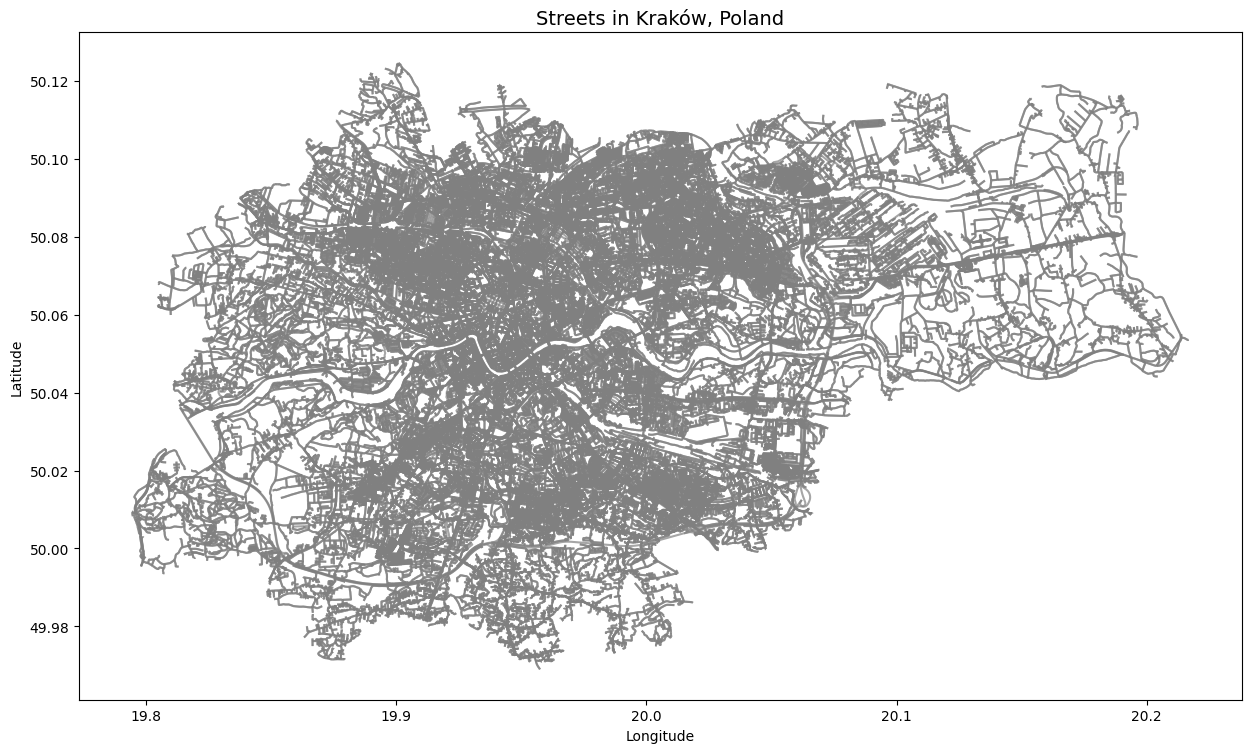

In [10]:
geo_simple_visualisation(osm_data.streets_df, f"Streets in {osm_data.place}")

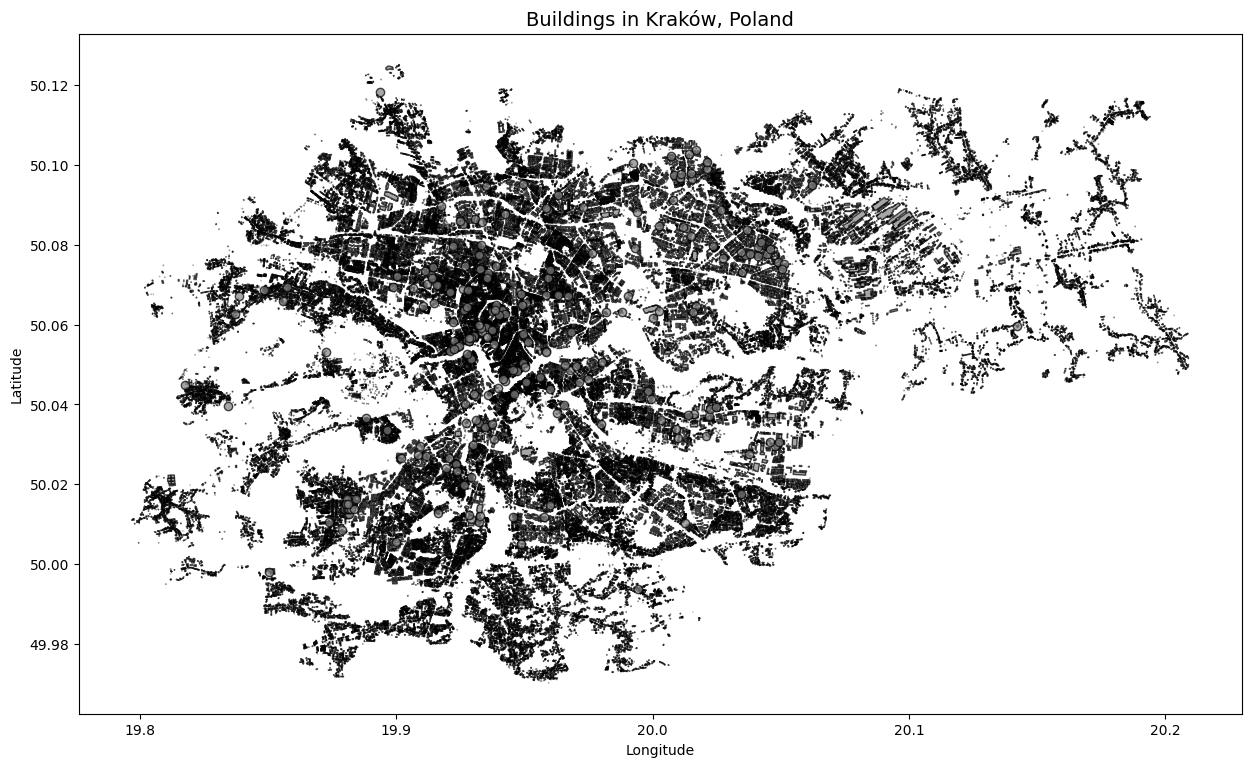

In [11]:
geo_simple_visualisation(osm_data.buildings_df, f"Buildings in {osm_data.place}")

### Visualisations of cycling infrastructure

In [12]:
local_data.bike_infrastructure_df

""


In [13]:
local_data.bike_racks_df

""


In [14]:
combined_cycling_infra = pd.concat([local_data.bike_racks_df, local_data.bike_infrastructure_df])
create_interactive_map(combined_cycling_infra, "typ")

In [15]:
local_data.cycling_paths_df

""


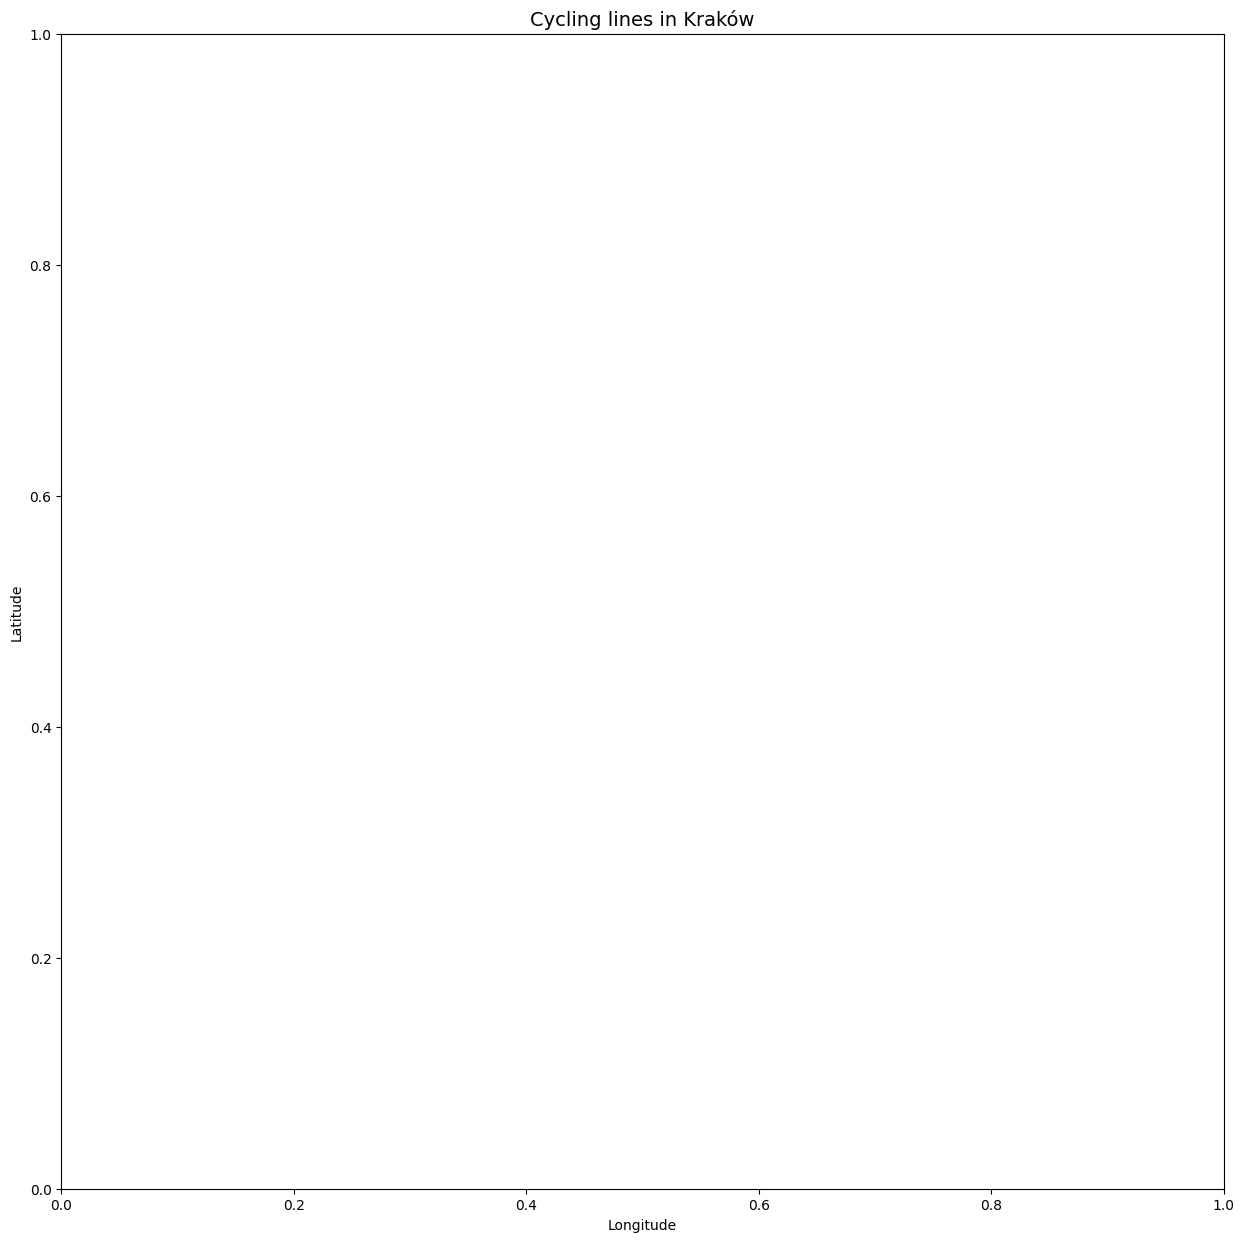

In [16]:
geo_simple_visualisation(local_data.cycling_paths_df, f"Cycling lines in Kraków", color = "blue")

### Contextual data 

In [17]:
# Data from Bike counters 
counter_data.counters_df

""


In [18]:
local_data.greenery_df

""


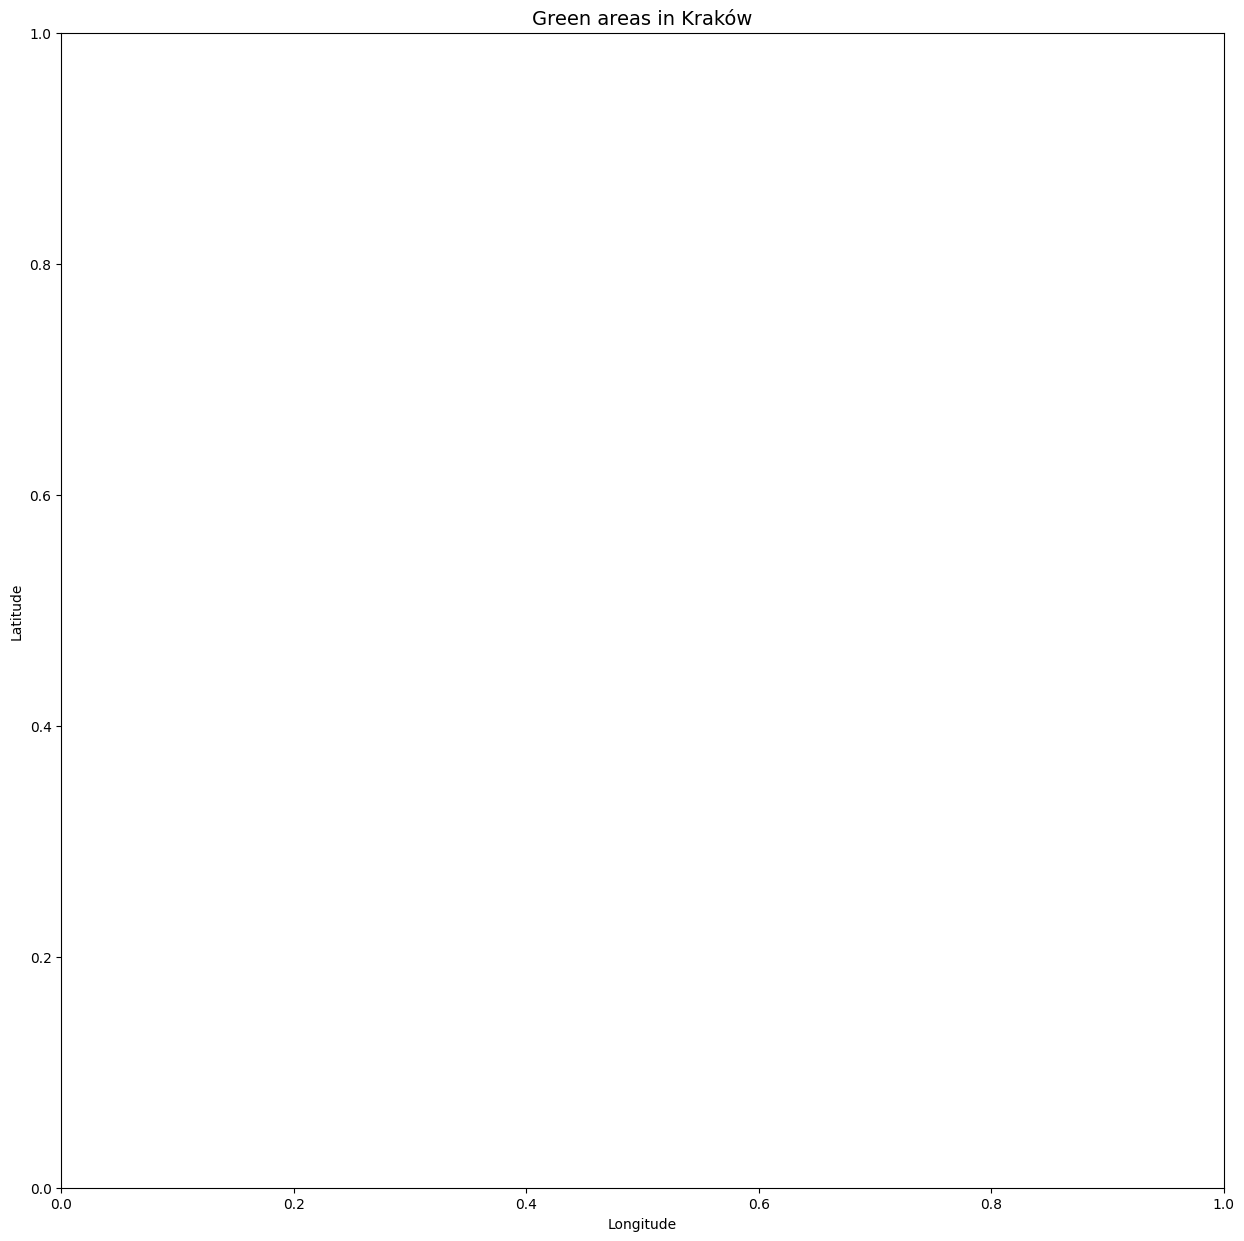

In [19]:
geo_simple_visualisation(local_data.greenery_df, "Green areas in Kraków", color= "green", edgecolor="green")

In [20]:
#Noise intensity heatmap
local_data.noise_map_df

""


AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

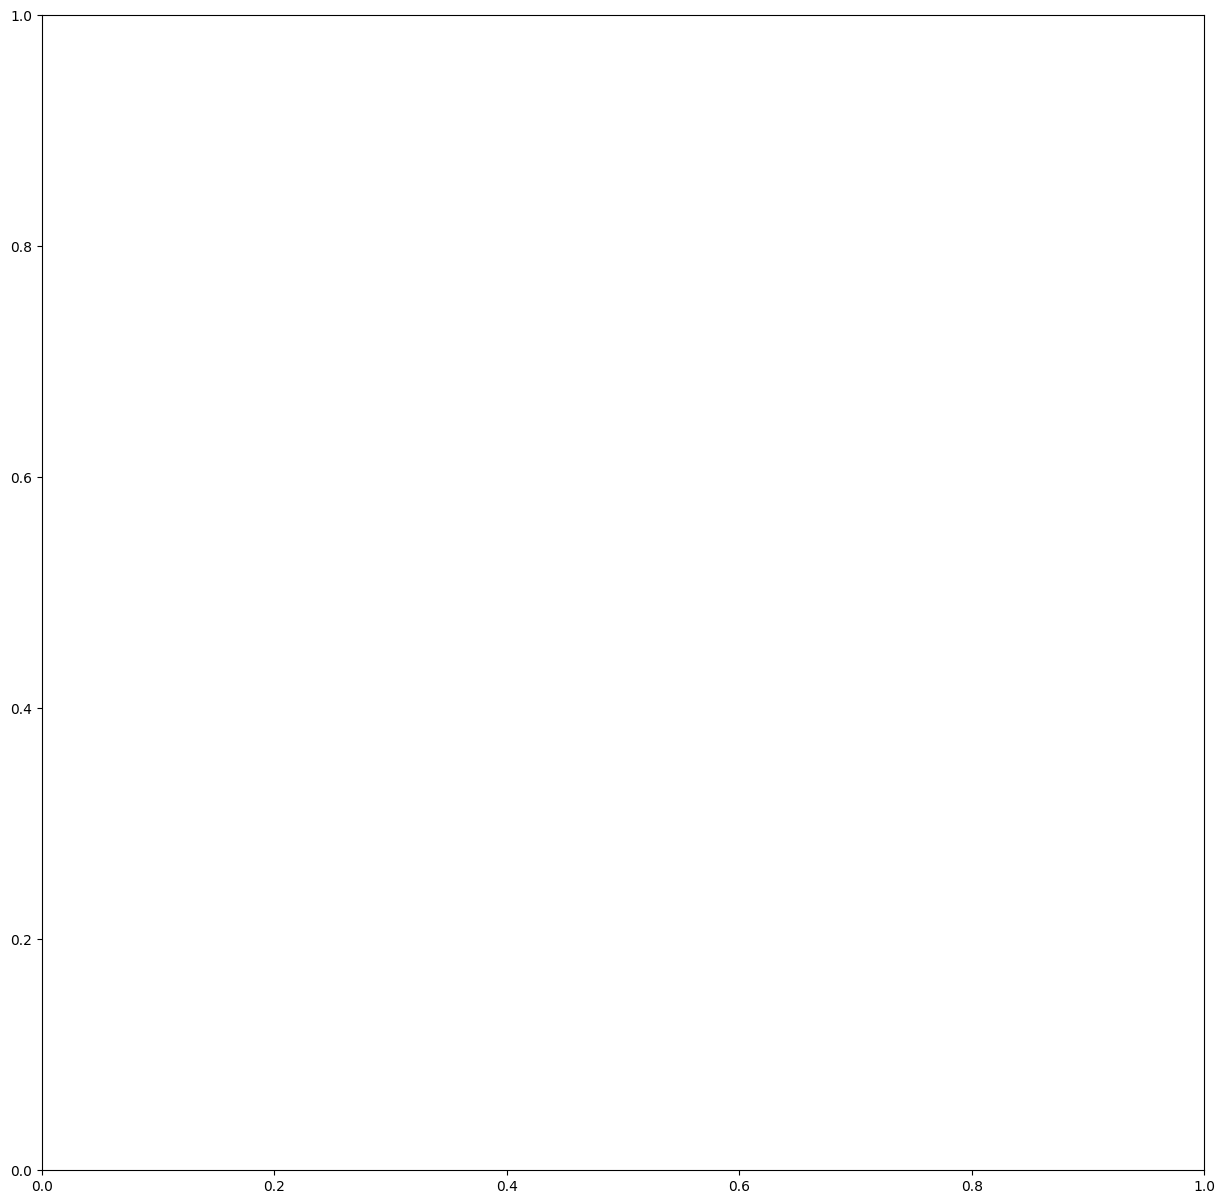

In [21]:
fig, ax = plt.subplots(figsize=(15, 15))

local_data.noise_map_df.plot(
    ax=ax, 
    column="isov1", 
    cmap="YlOrRd", 
    legend=True, 
    legend_kwds={'label': "Noise Intensity Level", 'orientation': "horizontal"},
    alpha=0.8
)

ax.set_title(  "Noise Intensity Heatmap in Kraków (isov1)", fontsize=16, fontweight='bold')
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
plt.show()